# Offline Preprocessing Starter (Python)

This notebook is the fully independent Python version of `offline_preprocessing_starter.m`. It shows a minimal offline EEG workflow on one example `.gdf` file:

- find the project and dataset
- open one offline run
- keep EEG channels and separate the auxiliary eye channels
- bandpass filter and regress out EOG
- make quick sanity-check plots
- build the task spectrogram using the same style as the MATLAB starter

The code is intentionally short, and each section explains what it is doing.

In [1]:
from pathlib import Path
import os

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == 'starter' else cwd
DATASET_ROOT = next((REPO_ROOT / name for name in ['BCI_Harmony_ExperimentalData', 'BCI_course_EXP'] if (REPO_ROOT / name).exists()), None)
assert DATASET_ROOT is not None, 'Could not find the dataset folder.'

os.environ.setdefault('MPLCONFIGDIR', str(REPO_ROOT / '.matplotlib'))

import matplotlib.pyplot as plt
import mne
import numpy as np
from scipy.signal import butter, filtfilt, spectrogram, welch

plt.rcParams['figure.dpi'] = 150

def bandpass(data, fs, low_hz, high_hz, order=2):
    b, a = butter(order, [low_hz, high_hz], btype='bandpass', fs=fs)
    return filtfilt(b, a, data, axis=0)

def get_event_table(raw):
    event_samples = np.rint(raw.annotations.onset * raw.info['sfreq']).astype(int)
    event_codes = np.array([int(desc) for desc in raw.annotations.description], dtype=int)
    return event_samples, event_codes

print('Repo root :', REPO_ROOT)
print('Dataset   :', DATASET_ROOT)

Repo root : /Users/kanishkamitra/Documents/UT/BMI_Harmony/bci_exo_startstop_ICRA_26
Dataset   : /Users/kanishkamitra/Documents/UT/BMI_Harmony/bci_exo_startstop_ICRA_26/BCI_Harmony_ExperimentalData


## 1) Choose one offline file

We keep this simple: just grab the first offline `.gdf` file in sorted order. That makes the notebook reproducible, but you can change `target_file` if you want to inspect a different run.

In [2]:
gdf_files = sorted((DATASET_ROOT / 'offline_data').glob('Sub_*/*offline*/*.gdf'))
assert gdf_files, 'No offline .gdf files found.'

target_file = gdf_files[0]
raw = mne.io.read_raw_gdf(target_file, preload=True, verbose='ERROR')
signal = raw.get_data().T
fs = float(raw.info['sfreq'])
chan_labels = np.array(raw.ch_names, dtype=str)
event_samples, event_codes = get_event_table(raw)

print(f'Loading: {target_file}')
print(f'Samples: {signal.shape[0]} | Channels: {signal.shape[1]} | Fs: {fs:.2f} Hz')
print('Unique trigger labels:', sorted(np.unique(event_codes).tolist()))
chan_labels[:10]

Loading: /Users/kanishkamitra/Documents/UT/BMI_Harmony/bci_exo_startstop_ICRA_26/BCI_Harmony_ExperimentalData/offline_data/Sub_1/Sub_1_run_1_10172023_1801_offline/Sub_1_run_1_offline.gdf
Samples: 210432 | Channels: 68 | Fs: 512.00 Hz
Unique trigger labels: [100, 150, 300, 500, 550, 900, 950, 1000, 2000]


array(['FP1', 'FPZ', 'FP2', 'F7', 'F3', 'FZ', 'F4', 'F8', 'FC5', 'FC1'],
      dtype='<U6')

## 2) Keep EEG channels and clean them

Here we split the data into EEG and auxiliary channels. In this dataset, the first 64 channels are EEG, the last three sensor channels (`sens7-9`) are the eye channels, and `Status` carries trigger information.

Then we do a very standard light preprocessing pass:

- remove a couple of frontal channels if you do not want them
- bandpass the EEG from 8 to 30 Hz
- regress out the eye channels

This is meant to stay small and readable, not be a full preprocessing pipeline.

In [3]:
labels_upper = np.char.upper(chan_labels)
manual_remove = np.array(['FP1', 'FP2'])
manual_mask = np.isin(labels_upper, manual_remove)
eog_mask = np.isin(np.arange(signal.shape[1]), [64, 65, 66]) | np.char.startswith(labels_upper, 'SENS')
status_mask = labels_upper == 'STATUS'
eeg_mask = ~(manual_mask | eog_mask | status_mask)

eeg_raw = signal[:, eeg_mask]
eeg_labels = chan_labels[eeg_mask]
eog = signal[:, eog_mask]
eog_labels = chan_labels[eog_mask]

eeg_bp = bandpass(eeg_raw, fs, 8.0, 30.0)
if eog.shape[1]:
    eog_bp = bandpass(eog, fs, 8.0, 30.0)
    beta, *_ = np.linalg.lstsq(eog_bp, eeg_bp, rcond=None)
    eeg_clean = eeg_bp - eog_bp @ beta
else:
    eeg_clean = eeg_bp.copy()

print('EEG channels kept:', eeg_clean.shape[1])
print('EOG channels used:', list(eog_labels))
print('First few EEG labels:', eeg_labels[:10].tolist())

EEG channels kept: 62
EOG channels used: ['sens7', 'sens8', 'sens9']
First few EEG labels: ['FPZ', 'F7', 'F3', 'FZ', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6']


## 3) Quick sanity-check plots

The left panel compares the average power spectrum before and after preprocessing. The right panel gives a simple time-frequency view of one cleaned EEG channel.

By default we try to show `C3`; if it is missing, we just plot the first kept channel.

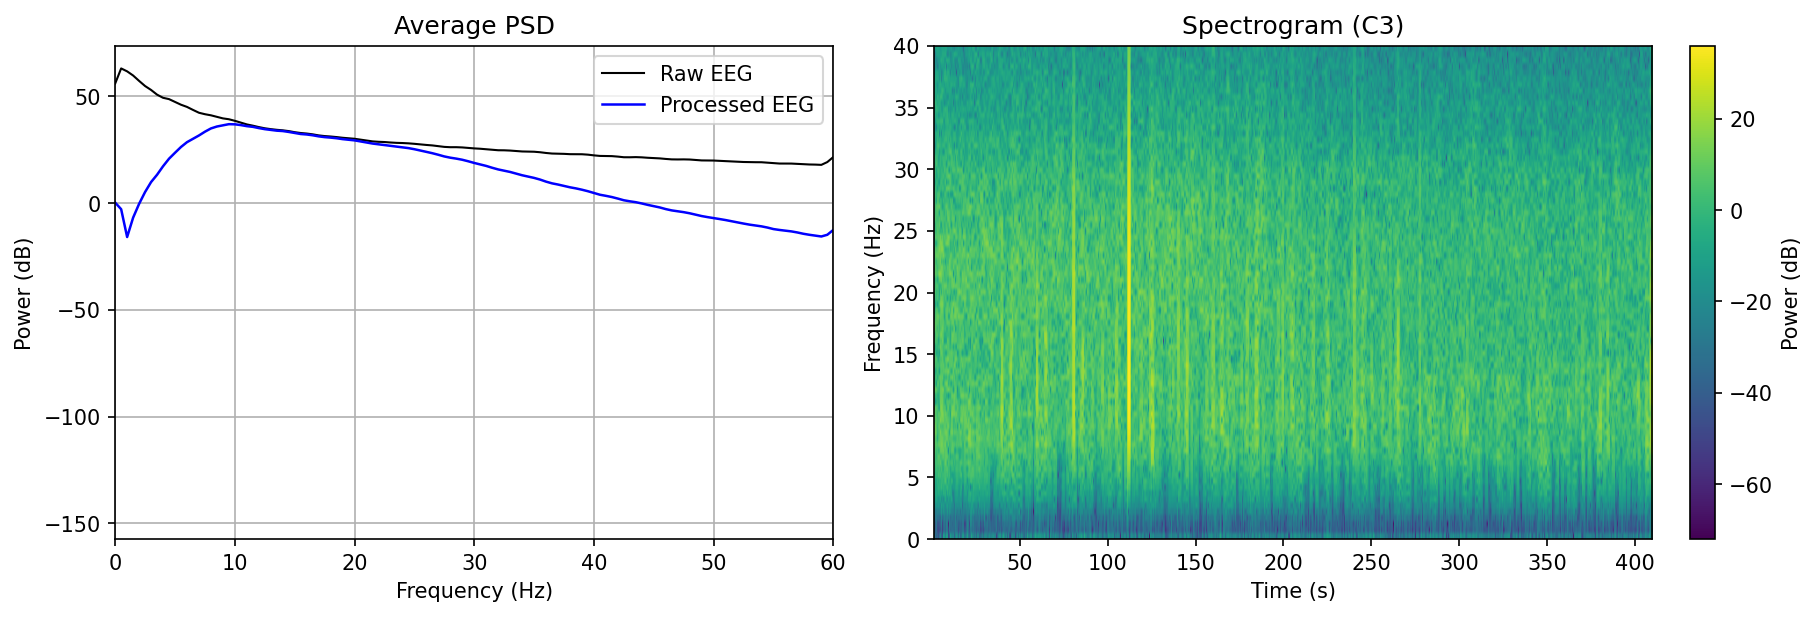

In [4]:
freq_psd, pxx_raw = welch(eeg_raw, fs=fs, nperseg=int(2 * fs), axis=0)
_, pxx_clean = welch(eeg_clean, fs=fs, nperseg=int(2 * fs), axis=0)

ch_plot = np.where(np.char.upper(eeg_labels) == 'C3')[0]
ch_plot = int(ch_plot[0]) if ch_plot.size else 0

freq_tf, time_tf, spec_tf = spectrogram(
    eeg_clean[:, ch_plot],
    fs=fs,
    nperseg=int(2 * fs),
    noverlap=int(1.5 * fs),
    nfft=int(2 * fs),
)
freq_mask = freq_tf <= 40

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(freq_psd, 10 * np.log10(np.mean(pxx_raw, axis=1) + np.finfo(float).eps), color='k', lw=1, label='Raw EEG')
axes[0].plot(freq_psd, 10 * np.log10(np.mean(pxx_clean, axis=1) + np.finfo(float).eps), color='b', lw=1.2, label='Processed EEG')
axes[0].set_xlim(0, 60)
axes[0].grid(True)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (dB)')
axes[0].set_title('Average PSD')
axes[0].legend(loc='upper right')

im = axes[1].imshow(
    10 * np.log10(spec_tf[freq_mask] + np.finfo(float).eps),
    aspect='auto',
    origin='lower',
    extent=[time_tf[0], time_tf[-1], freq_tf[freq_mask][0], freq_tf[freq_mask][-1]],
    cmap='viridis',
)
axes[1].set_ylim(0, 40)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title(f'Spectrogram ({eeg_labels[ch_plot]})')
fig.colorbar(im, ax=axes[1], label='Power (dB)')
plt.show()

## 4) Task spectrogram in the same style as the MATLAB starter

This block mirrors the MATLAB task-spectrogram cell:

- use the first 64 channels as EEG
- use channels 65:67 as EOG regressors
- bandpass from 0.1 to 45 Hz
- keep the same reduced 22-channel montage
- apply common average reference
- align trials to trigger `300`
- compute baseline-normalized Welch PSD
- plot the result with the same event markers

Change `spectrogram_channel` if you want a different channel from the reduced montage.

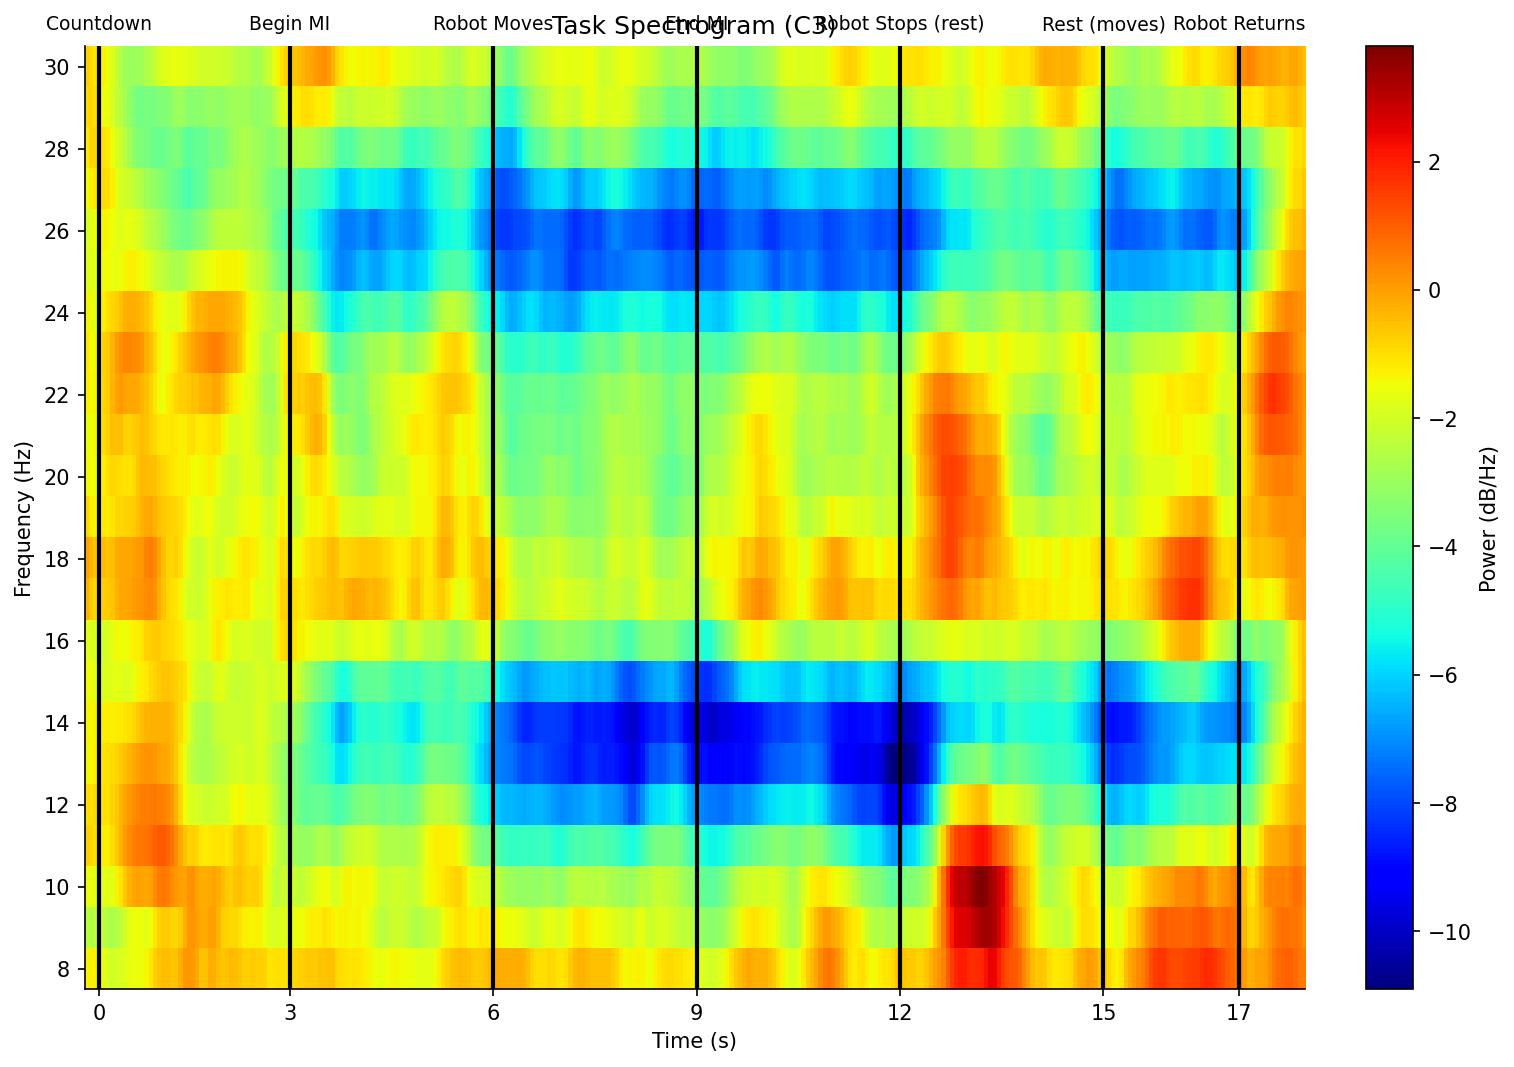

In [5]:
spectrogram_channel = 'C3'
spec_keep_idx = np.r_[4:13, 15:18, 20:30] - 1
spec_data = signal[:event_samples[-1], :]
spec_eeg = spec_data[:, :64]
spec_eog = spec_data[:, 64:67]
spec_labels = chan_labels[:64][spec_keep_idx]
spec_ch_idx = np.where(np.char.upper(spec_labels) == spectrogram_channel.upper())[0]
assert spec_ch_idx.size, 'Requested spectrogram channel was not found.'
spec_ch_idx = int(spec_ch_idx[0])

spec_eeg = bandpass(spec_eeg, fs, 0.1, 45.0)
if spec_eog.shape[1]:
    spec_eog = bandpass(spec_eog, fs, 0.1, 45.0)
    spec_beta, *_ = np.linalg.lstsq(spec_eog, spec_eeg, rcond=None)
    spec_eeg = spec_eeg - spec_eog @ spec_beta

spec_eeg = spec_eeg[:, spec_keep_idx]
spec_eeg = spec_eeg - spec_eeg.mean(axis=1, keepdims=True)

countdown_pos = event_samples[event_codes == 300]
countdown_pos = countdown_pos[(countdown_pos - 2 * fs >= 0) & (countdown_pos + 18 * fs <= spec_eeg.shape[0])]
assert countdown_pos.size, 'No valid countdown triggers were found for spectrogram trials.'

window_size = 1.0
baseline_window_size = 2.0
step_size = 0.0625
step_samples = int(round(step_size * fs))
num_windows = int(round(1 / step_size))
num_trial_windows = int(round(18 / step_size))
num_baseline_windows = int(round((baseline_window_size - window_size) / step_size + 1))
freq_keep = np.arange(8, 31)

epochs_freq = np.zeros((freq_keep.size, num_trial_windows, countdown_pos.size))
baseline_epochs_freq = np.zeros((freq_keep.size, num_baseline_windows, countdown_pos.size))

for trial_idx, start in enumerate(countdown_pos.astype(int)):
    curr = start
    for win_idx in range(num_trial_windows):
        freq_axis, pxx = welch(
            spec_eeg[curr:curr + int(fs), spec_ch_idx],
            fs=fs,
            window='hamming',
            nperseg=int(0.5 * fs),
            noverlap=int(round(0.4 * fs)),
            nfft=int(fs),
        )
        epochs_freq[:, win_idx, trial_idx] = pxx[(freq_axis >= 8) & (freq_axis <= 30)]
        curr += step_samples

    curr = start - int(2 * fs)
    for win_idx in range(num_baseline_windows):
        freq_axis, pxx = welch(
            spec_eeg[curr:curr + int(fs), spec_ch_idx],
            fs=fs,
            window='hamming',
            nperseg=int(0.5 * fs),
            noverlap=int(round(0.4 * fs)),
            nfft=int(fs),
        )
        baseline_epochs_freq[:, win_idx, trial_idx] = pxx[(freq_axis >= 8) & (freq_axis <= 30)]
        curr += step_samples

baseline_mean = baseline_epochs_freq.mean(axis=1)
epochs_freq_bld = epochs_freq / baseline_mean[:, None, :]
PSD_matrix = np.flipud(10 * np.log10(epochs_freq_bld).mean(axis=2))
freq_plot = freq_keep[::-1]

event_x = np.rint(np.array([0.2, 3.0, 6.0, 9.0, 12.0, 15.0, 17.0]) * num_windows).astype(int)
event_labels = ['Countdown', 'Begin MI', 'Robot Moves', 'End MI', 'Robot Stops (rest)', 'Rest (moves)', 'Robot Returns']

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
im = ax.imshow(PSD_matrix, aspect='auto', cmap='jet', origin='upper')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Power (dB/Hz)')

for x, label in zip(event_x, event_labels):
    ax.axvline(x, color='k', linewidth=2)
    ax.text(x, -0.8, label, ha='center', va='bottom', fontsize=9, clip_on=False)

ax.set_xticks(event_x)
ax.set_xticklabels(['0', '3', '6', '9', '12', '15', '17'])
ax.set_yticks(np.arange(0, len(freq_plot), 2))
ax.set_yticklabels(freq_plot[::2])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title(f'Task Spectrogram ({spec_labels[spec_ch_idx]})')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

## 5) What to change most often

If someone else wants to reuse this notebook, the main knobs are:

- `target_file` if they want a different offline run
- `manual_remove` if they want to drop different EEG channels
- `spectrogram_channel` if they want a channel other than `C3`

Everything else is kept intentionally simple so the preprocessing steps are easy to follow.